In [1]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import scienceplots
plt.style.use(['science', 'nature', 'grid'])

import numpy as np
from scipy.interpolate import interp1d
import pandas as pd

from LoadMoments import *
from LoadTSV import *

In [3]:
WIDTH = 6.0 
HEIGHT = 5.0

plt.rcParams.update({
    "figure.figsize": (WIDTH, HEIGHT),
    "font.size": 10,           # Matches thesis 10pt
    "axes.labelsize": 10,
    "legend.fontsize": 8,      # Slightly smaller for legends
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.linewidth": 1,
    "lines.markersize": 4,
    "savefig.bbox": 'tight',   # Ensures no labels are cut off
    "savefig.pad_inches": 0.05
})

In [4]:
# Plotting
colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown']
linestyles = ['-', '--', ':', '-.', (0, (3, 1, 1, 1)), (0, (5, 1))]

In [6]:
M = 4
closure = "ExtGram"
Kn = 1.0
source = "relaxation_source"
source_string = source
T_end = 15.0
base_tree_level = 8
polydeg = 1

# Initial condition parameters for the Riemann problem
rho_L = 1.0
v_L1 = 1.0
v_L2 = 0.0
v_L3 = 0.0
theta_L = 1/3
rho_R = 1.0
v_R1 = -1.0
v_R2 = 0.0
v_R3 = 0.0
theta_R = 1/3

x_lower = -30.0
x_upper = 30.0

anglepairnumber = 0

In [8]:
name = f"../out/1D3D/1D3D_angles/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source_string}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L1{v_L1}_v_L2{v_L2}_v_L3{v_L3}_v_R1{v_R1}_v_R2{v_R2}_v_R3{v_R3}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_anglepairnumber{anglepairnumber}"

/tmp/ipykernel_23888/657201585.py:18: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


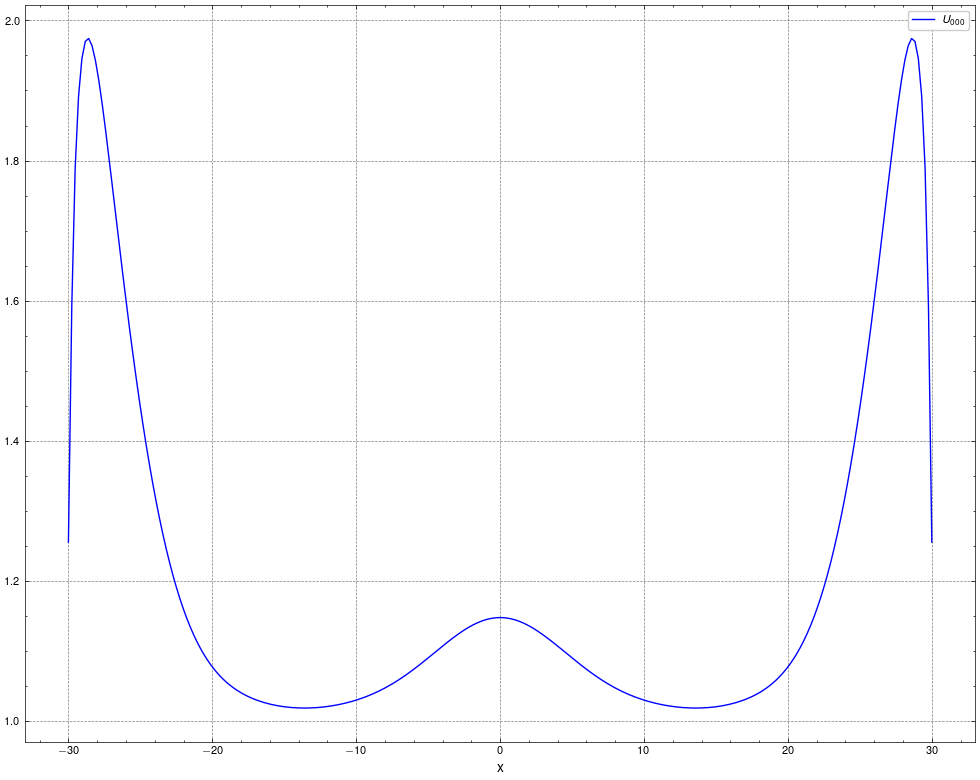

In [11]:
# Conservative Moments
data = read_solution_file(name + "_cons.tsv")

# Build time → timestep mapping
times = np.array([data[ts]["t"] for ts in sorted(data.keys())])
timesteps = np.array(sorted(data.keys()))

time_query = 21 # last time step
sol = interpolate_solution(data, time_query, times, timesteps)
x, U, t = sol["x"], sol["u"], sol["t"]

fig, axs = plt.subplots(figsize=(10, 8))
axs.plot(x, U[:, 0], label="$U_{000}$", color=colors[0])
axs.set_xlabel("x")
axs.grid(True)
axs.legend()
fig.tight_layout()
fig.show()

/tmp/ipykernel_23888/170123137.py:18: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


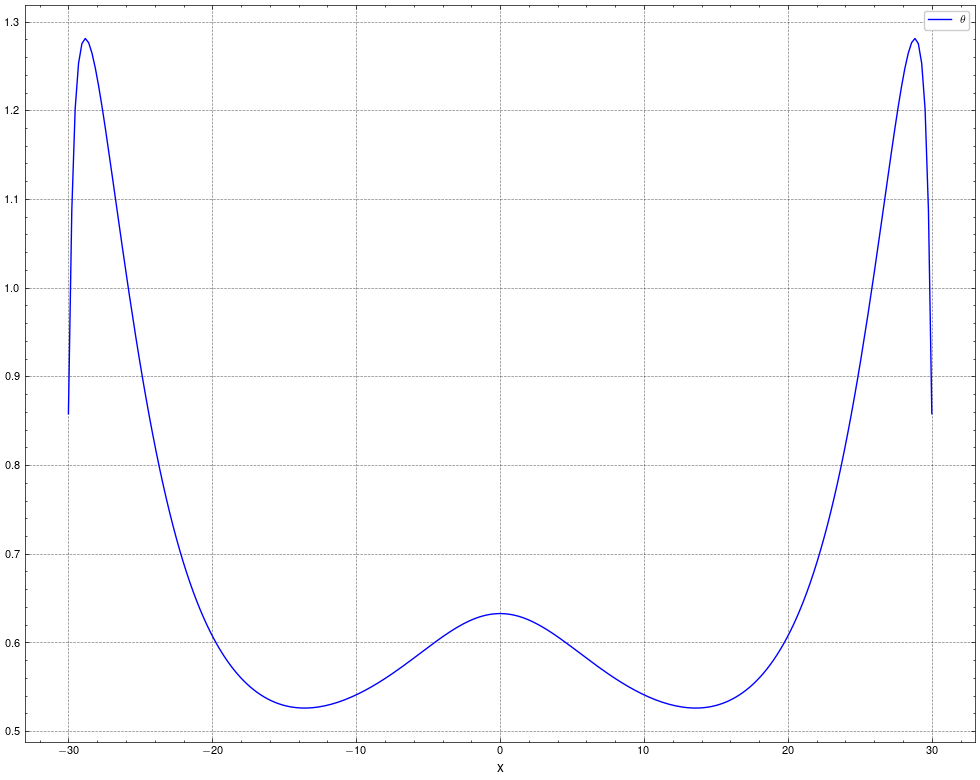

In [12]:
# Conservative Moments
data = read_solution_file(name + "_cons.tsv")

# Build time → timestep mapping
times = np.array([data[ts]["t"] for ts in sorted(data.keys())])
timesteps = np.array(sorted(data.keys()))

time_query = 21 # last time step
sol = interpolate_solution(data, time_query, times, timesteps)
x, U, t = sol["x"], sol["u"], sol["t"]

fig, axs = plt.subplots(figsize=(10, 8))
axs.plot(x, 1/3 * (U[:, 2] + 2 * U[:, 3]), label="$\\theta$", color=colors[0])
axs.set_xlabel("x")
axs.grid(True)
axs.legend()
fig.tight_layout()
fig.show()